In [1]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

In [2]:
version = 'SP_v1.4.1'
data = fits.open(f'data/{version}/cosmosis_{version}.fits')

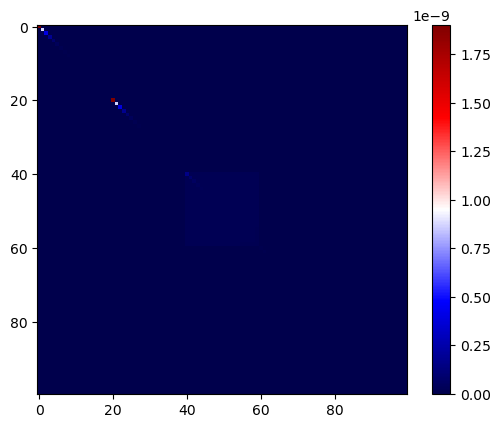

In [5]:
plt.imshow(data["COVMAT"].data, cmap='seismic')
plt.colorbar()

In [12]:
data['XI_PLUS'].data['ANG']

array([1.2526e-01, 1.8519e-01, 2.7396e-01, 4.0534e-01, 5.9962e-01,
       8.8698e-01, 1.3117e+00, 1.9400e+00, 2.8687e+00, 4.2414e+00,
       6.2733e+00, 9.2868e+00, 1.3733e+01, 2.0310e+01, 3.0028e+01,
       4.4398e+01, 6.5627e+01, 9.7018e+01, 1.4341e+02, 2.1199e+02])

In [18]:
min = 1.0
max = 200.0

mask = (data['XI_PLUS'].data['ANG'] >= min) & (data['XI_PLUS'].data['ANG'] <= max)

In [19]:
data['XI_PLUS'].data['ANG'][mask].shape

(13,)

## PSF leakage parameters

In [41]:
version = 'SP_v1.4.1_noleakage'
samples = np.load(f'/home/guerrini/sp_validation/notebooks/cosmo_val/output/rho_tau_stats/samples_{version}.npy')

In [42]:
parameters = np.mean(samples, axis=0)

print(f'alpha = {parameters[0]}')
print(f'beta = {parameters[1]}')
print(f'eta = {parameters[2]}')

alpha = 0.002676328787967068
beta = 1.074303550642046
eta = 0.0045222401216410265


In [43]:
cov_parameters = np.cov(samples.T)
corr_parameters = np.corrcoef(samples.T)

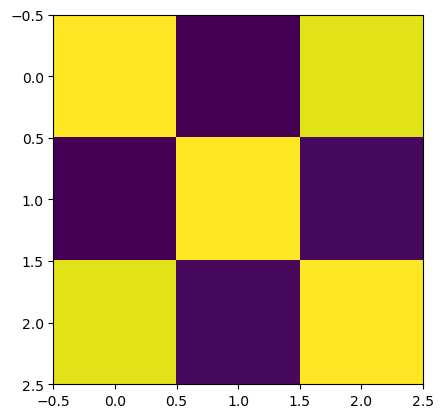

In [44]:
plt.imshow(corr_parameters)

In [45]:
corr_parameters

array([[1.        , 0.26092814, 0.96717155],
       [0.26092814, 1.        , 0.27993402],
       [0.96717155, 0.27993402, 1.        ]])

In [46]:
np.std(samples, axis=0)

array([0.00848568, 0.09052625, 1.09534687])

In [47]:
from scipy.optimize import curve_fit

def get_degeneracy_direction(samples):
    alpha_samples = samples[:, 0]
    eta_samples = samples[:, 2]

    def objective(x, a, b):
        return a*x + b
    
    popt, _ = curve_fit(objective, alpha_samples, eta_samples)

    return popt

In [48]:
get_degeneracy_direction(samples)

array([124.84426424,  -0.32960206])

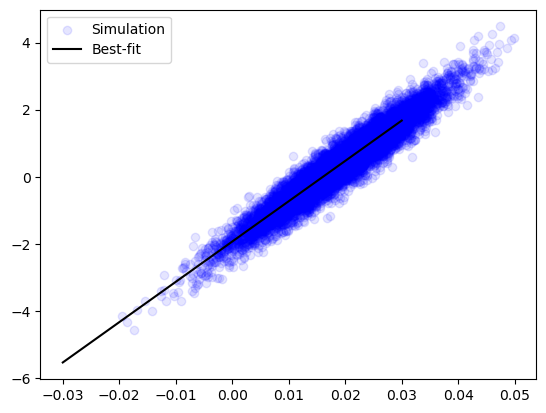

In [40]:
plt.figure()

plt.scatter(samples[:, 0], samples[:, 2], c='b', label='Simulation', alpha=0.1)
x = np.linspace(-0.03, 0.03)
a, b = get_degeneracy_direction(samples)
plt.plot(x, a*x + b, c='black', label='Best-fit')
plt.legend()
plt.show()